In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)
np.warnings = warnings

import torch
import random
import math
import sys
sys.path.append("../..")  # Add parent directory to path
sys.path.append("../../../..")
from hartmann3d_synth import Hartmann3D
import scipy
import matplotlib
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


tensor([0.0070, 0.5568, 0.1674, 0.1993, 0.0695])
Iteration 1/20, Current best: 1.0028, 


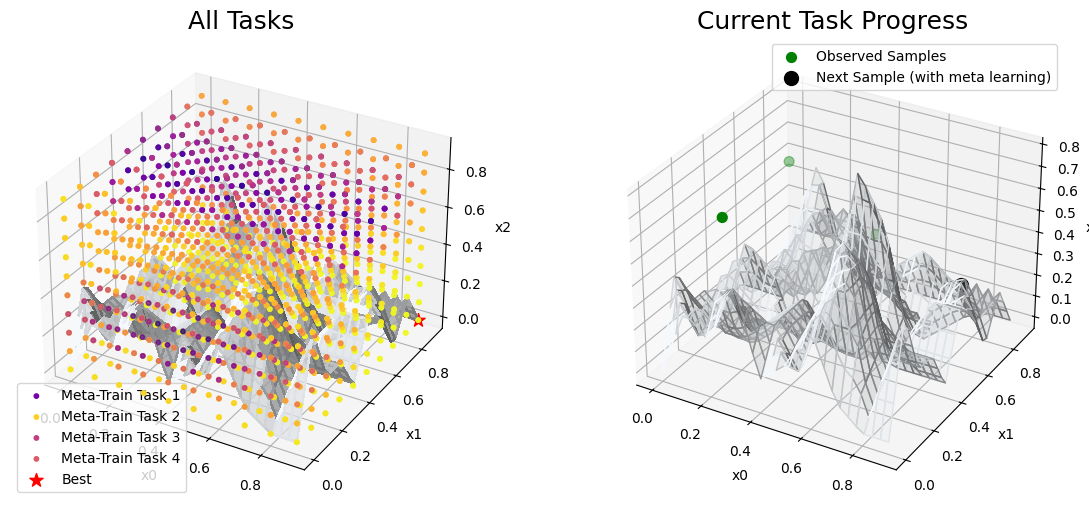

tensor([0.0096, 0.5370, 0.1692, 0.2092, 0.0749])
Iteration 2/20, Current best: 1.0020, 


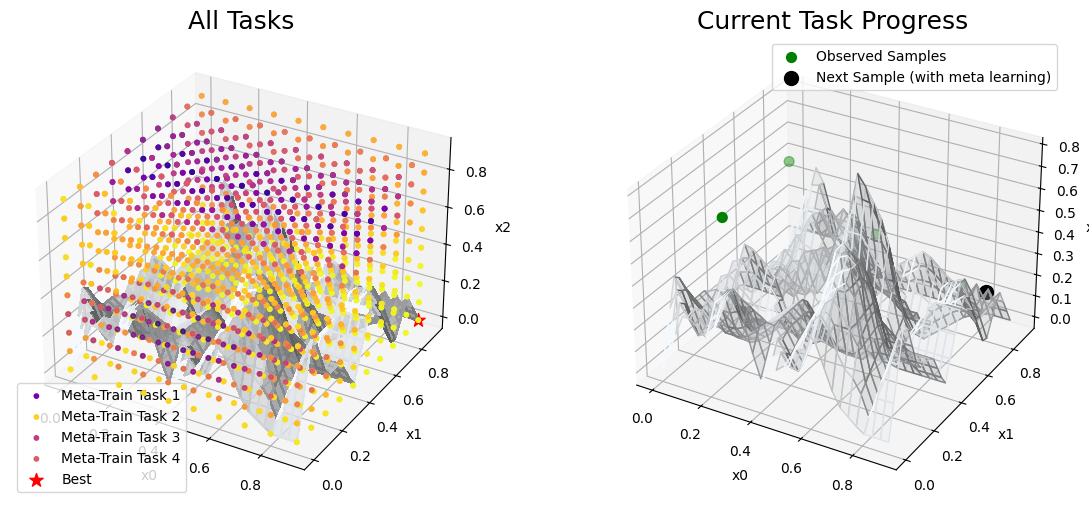

tensor([0.0156, 0.5141, 0.1746, 0.2141, 0.0817])
Iteration 3/20, Current best: 1.0003, 


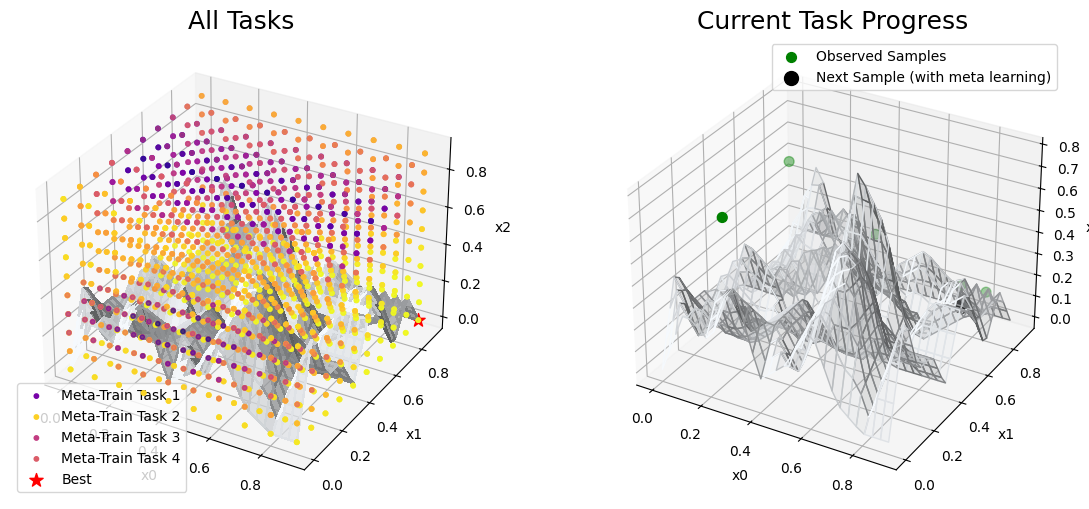

KeyboardInterrupt: 

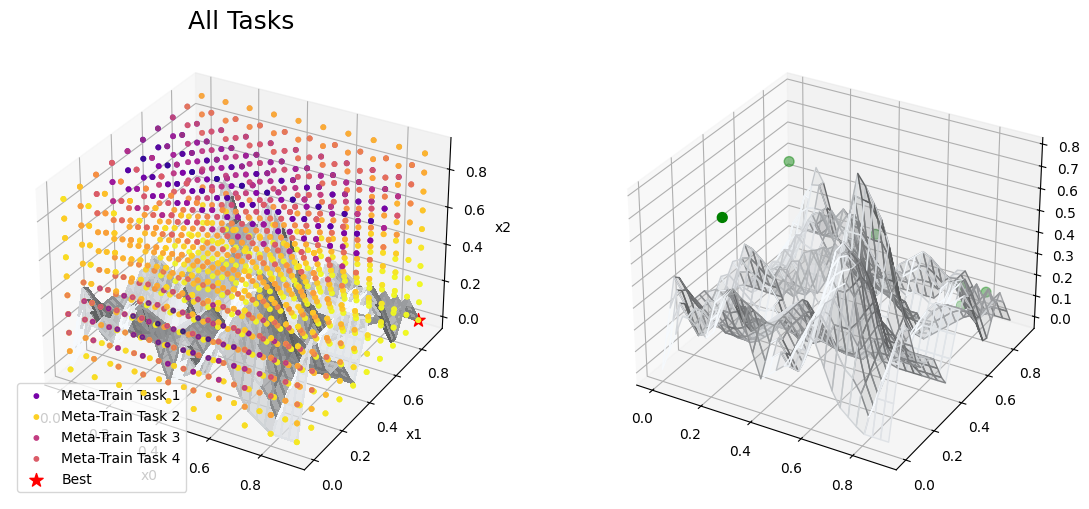

In [18]:
test_seed = "test1"
task_id = 0  # Task ID for the SimpleSynth benchmark
max_evaluations = 20

benchmark = Hartmann3D(seed=test_seed, start_task=task_id, initializations=3)


fontsize = 18
lw=2

import pfns4bo
from mpfns4bo.mpfns4bo import MPFNs4BO
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
meta_data = benchmark.get_meta_data()
optimizer = MPFNs4BO(torch.load( pfns4bo.hebo_plus_model), benchmark.search_space, meta_data, apply_power_transform=False,
                      only_obs_incumbents=True, tranformation_type=None, mixing_strategy="my",)




X = np.asarray(benchmark.benchmark_data["X"])
y = np.asarray(benchmark.benchmark_data["y"])
y = 1 - y

data_size = len(X)
# indices of pending evaluations
pending_evaluations = list(range(data_size))
current_evaluations = []

init_ids = benchmark.bo_initializations[test_seed]
for i in range(len(init_ids)):
    idx = init_ids[i]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)


min_regret_history = [np.min(y[current_evaluations])]
opt_time = []
for iteration in range(max_evaluations):
    fig = plt.figure(figsize=(14, 6))
    axs = [fig.add_subplot(121, projection='3d'), fig.add_subplot(122, projection='3d')]

    not_init = np.setdiff1d(np.arange(data_size), init_ids)
    # Surface plot instead of scatter for the downstream task
    # Create grid for surface plot
    grid_x, grid_y = np.meshgrid(
        np.linspace(X[not_init, 0].min(), X[not_init, 0].max(), 30),
        np.linspace(X[not_init, 1].min(), X[not_init, 1].max(), 30)
    )
    # Interpolate values for z
    grid_z = griddata(
        X[not_init, :2], X[not_init, 2], (grid_x, grid_y), method='linear'
    )
    grid_val = griddata(
        X[not_init, :3], 1 - y[not_init], (grid_x, grid_y, grid_z), method='linear'
    )
    # Plot the surface in blue, faster with lower resolution
    axs[0].plot_surface(grid_x, grid_y, grid_z, facecolors=plt.cm.Blues(grid_val), rstride=1, cstride=1, alpha=0.7, antialiased=False)

    task_names = ["Meta-Train Task 1", "Meta-Train Task 2", "Meta-Train Task 3", "Meta-Train Task 4", "Meta-Train Task 5"]

    for i, (k, mdata) in enumerate(meta_data.items()):
        mX = np.array([benchmark.search_space.to_numerical(e.configuration) for e in mdata])
        mY = - np.array([e.objectives["loss"] for e in mdata]).reshape(-1)
        axs[0].scatter(mX[:, 0], mX[:, 1], mX[:, 2], c=mY, cmap='plasma', s=10, label=task_names[i])

    axs[0].scatter(X[y.argmin(), 0], X[y.argmin(), 1], X[y.argmin(), 2], marker="*", s=100, c="red", label="Best", zorder=99)
    axs[0].set_title("All Tasks", fontsize=fontsize)
    axs[0].set_xlabel("x0")
    axs[0].set_ylabel("x1")
    axs[0].set_zlabel("x2")
    axs[0].legend()

    not_evaluated = np.setdiff1d(np.arange(data_size), current_evaluations)
    # Surface plot for the downstream task (not yet evaluated points)
    # Create grid for surface plot using not_evaluated indices
    grid_x, grid_y = np.meshgrid(
        np.linspace(X[not_evaluated, 0].min(), X[not_evaluated, 0].max(), 30),
        np.linspace(X[not_evaluated, 1].min(), X[not_evaluated, 1].max(), 30)
    )
    grid_z = griddata(
        X[not_evaluated, :2], X[not_evaluated, 2], (grid_x, grid_y), method='linear'
    )
    grid_val = griddata(
        X[not_evaluated, :3], 1 - y[not_evaluated], (grid_x, grid_y, grid_z), method='linear'
    )
    axs[1].plot_surface(grid_x, grid_y, grid_z, facecolors=plt.cm.Blues(grid_val), rstride=1, cstride=1, alpha=0.2, antialiased=True)


    axs[1].scatter(X[current_evaluations, 0], X[current_evaluations, 1], X[current_evaluations, 2], s=50, c="green", label="Observed Samples", zorder=99)
    idx = optimizer.observe_and_suggest(
        X[current_evaluations], y[current_evaluations], X[pending_evaluations]
    )
    axs[1].scatter(X[pending_evaluations][idx, 0], X[pending_evaluations][idx, 1], X[pending_evaluations][idx, 2], s=100, c="black", label="Next Sample (with meta learning)", zorder=99)
    idx = pending_evaluations[idx]
    pending_evaluations.remove(idx)
    current_evaluations.append(idx)
    min_regret_history.append(np.min(y[current_evaluations]))

    axs[1].set_title("Current Task Progress", fontsize=fontsize)
    axs[1].set_xlabel("x0")
    axs[1].set_ylabel("x1")
    axs[1].set_zlabel("x2")
    axs[1].legend()

    print(optimizer.pfnimputation.reliability_scores)
    print(f"Iteration {iteration + 1}/{max_evaluations}, "
          f"Current best: {min_regret_history[-1]:.4f}, ")

    plt.show()

    if min(y) in min_regret_history:
        break

# negate to recover accuracy
min_regret_history += [min(y).item()] * (max_evaluations - i - 1)